# Log Loss (Cross-Entropy Loss)

This notebook demonstrates the calculation and properties of log loss, the fundamental loss function for classification tasks in machine learning.

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import sympy as sp

# ============================================================================
# Helper Functions for Log Loss Calculation
# ============================================================================

def binary_log_loss(y_true, y_pred):
    """
    Calculate binary cross-entropy loss (log loss).
    
    Parameters:
    -----------
    y_true : array-like
        True binary labels (0 or 1)
    y_pred : array-like
        Predicted probabilities (values between 0 and 1)
    
    Returns:
    --------
    float or ndarray
        Log loss value(s). If inputs are scalars, returns scalar.
        If inputs are arrays, returns loss for each sample or mean loss.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return -(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))


def mean_binary_log_loss(y_true, y_pred):
    """
    Calculate mean binary cross-entropy loss across all samples.
    
    Parameters:
    -----------
    y_true : array-like
        True binary labels
    y_pred : array-like
        Predicted probabilities
    
    Returns:
    --------
    float
        Mean log loss value
    """
    losses = binary_log_loss(y_true, y_pred)
    return np.mean(losses)


def multiclass_log_loss(y_true, y_pred_probs):
    """
    Calculate multi-class cross-entropy loss.
    
    Parameters:
    -----------
    y_true : array-like
        True class labels (0-indexed)
    y_pred_probs : 2D array-like
        Predicted probabilities for each class (samples x classes)
    
    Returns:
    --------
    float
        Mean log loss value for multi-class classification
    """
    y_true = np.asarray(y_true)
    y_pred_probs = np.asarray(y_pred_probs)
    
    individual_losses = 0
    for i in range(len(y_true)):
        true_class = y_true[i]
        pred_prob = y_pred_probs[i, true_class]
        individual_losses += -np.log(pred_prob)
    
    return individual_losses / len(y_true)

## What is Log Loss (Cross-Entropy Loss)?

**Log Loss** (also called **Binary Cross-Entropy** or **Cross-Entropy Loss**) is a loss function that measures the difference between predicted probabilities and actual binary labels. It penalizes confident incorrect predictions heavily.

### Mathematical Definition

**For Binary Classification:**

For a single prediction:
$$L(y_{true}, p_{pred}) = -[y_{true} \log(p_{pred}) + (1-y_{true})\log(1-p_{pred})]$$

For multiple predictions (Mean Log Loss):
$$\text{LogLoss} = -\frac{1}{n}\sum_{i=1}^{n}[y_i \log(p_i) + (1-y_i)\log(1-p_i)]$$

**For Multi-class Classification:**
$$\text{LogLoss} = -\frac{1}{n}\sum_{i=1}^{n}\sum_{j=1}^{K} y_{ij} \log(p_{ij})$$

where $y_{ij}$ is 1 if sample $i$ belongs to class $j$, and $p_{ij}$ is the predicted probability for class $j$.

### Key Properties

1. **Non-negative**: Loss is always ≥ 0
2. **Unbounded**: Loss approaches infinity as predicted probability approaches 0 (for true label 1) or 1 (for true label 0)
3. **Probability-based**: Expects predicted values to be probabilities (0 to 1)
4. **Penalizes confidence**: Heavily penalizes confident incorrect predictions
5. **Used for classification**: Specifically designed for binary and multi-class classification

### Why Use Log Loss?

- Good for probability calibration
- Penalizes overconfident wrong predictions
- Standard for classification competitions
- Has clear probabilistic interpretation (related to likelihood)
- Differentiable: enables gradient descent optimization

## Example 1: Single Binary Prediction

In [9]:
# Calculate log loss for single binary predictions

print("="*70)
print("Example 1: Single Binary Classification Predictions")
print("="*70)
print()

# Scenario 1: Correct prediction with high confidence
y_true_1 = 1
p_pred_1 = 0.95

log_loss_1 = binary_log_loss(y_true_1, p_pred_1)

print(f"Scenario 1: Correct prediction (high confidence)")
print(f"  True label:        y = {y_true_1}")
print(f"  Predicted prob:    p = {p_pred_1}")
print(f"  Log Loss:          L = {log_loss_1:.6f}")
print()

# Scenario 2: Correct prediction with low confidence
y_true_2 = 1
p_pred_2 = 0.51

log_loss_2 = binary_log_loss(y_true_2, p_pred_2)

print(f"Scenario 2: Correct prediction (low confidence)")
print(f"  True label:        y = {y_true_2}")
print(f"  Predicted prob:    p = {p_pred_2}")
print(f"  Log Loss:          L = {log_loss_2:.6f}")
print()

# Scenario 3: Incorrect prediction with high confidence
y_true_3 = 1
p_pred_3 = 0.05

log_loss_3 = binary_log_loss(y_true_3, p_pred_3)

print(f"Scenario 3: Incorrect prediction (high confidence)")
print(f"  True label:        y = {y_true_3}")
print(f"  Predicted prob:    p = {p_pred_3}")
print(f"  Log Loss:          L = {log_loss_3:.6f}")
print()

# Scenario 4: Completely wrong prediction at extreme
y_true_4 = 1
p_pred_4 = 0.01

log_loss_4 = binary_log_loss(y_true_4, p_pred_4)

print(f"Scenario 4: Extremely incorrect prediction")
print(f"  True label:        y = {y_true_4}")
print(f"  Predicted prob:    p = {p_pred_4}")
print(f"  Log Loss:          L = {log_loss_4:.6f}")
print()

print("Key observation: Confident wrong predictions have much higher loss!")
print(f"Scenario 2 loss ({log_loss_2:.4f}) < Scenario 1 loss ({log_loss_1:.4f})")
print(f"Scenario 3 loss ({log_loss_3:.4f}) >> Scenario 2 loss ({log_loss_2:.4f})")

Example 1: Single Binary Classification Predictions

Scenario 1: Correct prediction (high confidence)
  True label:        y = 1
  Predicted prob:    p = 0.95
  Log Loss:          L = 0.051293

Scenario 2: Correct prediction (low confidence)
  True label:        y = 1
  Predicted prob:    p = 0.51
  Log Loss:          L = 0.673345

Scenario 3: Incorrect prediction (high confidence)
  True label:        y = 1
  Predicted prob:    p = 0.05
  Log Loss:          L = 2.995732

Scenario 4: Extremely incorrect prediction
  True label:        y = 1
  Predicted prob:    p = 0.01
  Log Loss:          L = 4.605170

Key observation: Confident wrong predictions have much higher loss!
Scenario 2 loss (0.6733) < Scenario 1 loss (0.0513)
Scenario 3 loss (2.9957) >> Scenario 2 loss (0.6733)


## Example 2: Multiple Binary Predictions

In [10]:
# Calculate log loss for multiple binary classification predictions

y_true = np.array([1, 0, 1, 1, 0, 1, 0, 1])
y_pred_probs = np.array([0.9, 0.2, 0.8, 0.6, 0.3, 0.95, 0.1, 0.7])

print()
print("="*70)
print("Example 2: Multiple Binary Predictions (Mean Log Loss)")
print("="*70)
print()

# Calculate individual log losses
individual_losses = binary_log_loss(y_true, y_pred_probs)
mean_log_loss = np.mean(individual_losses)

print("Predictions:")
print(f"{'Sample':<8} {'True':<8} {'Predicted':<12} {'Loss':<12}")
print("-" * 50)
for i in range(len(y_true)):
    correct = "✓" if (y_true[i] == 1 and y_pred_probs[i] > 0.5) or (y_true[i] == 0 and y_pred_probs[i] <= 0.5) else "✗"
    print(f"{i+1:<8} {y_true[i]:<8} {y_pred_probs[i]:<12.3f} {individual_losses[i]:<12.6f}")
print()
print(f"Manual calculation (mean): {mean_log_loss:.6f}")
print()
print(f"Sum of losses:    {np.sum(individual_losses):.6f}")
print(f"Number of samples: {len(y_true)}")
print(f"Mean Log Loss:    {mean_log_loss:.6f}")


Example 2: Multiple Binary Predictions (Mean Log Loss)

Predictions:
Sample   True     Predicted    Loss        
--------------------------------------------------
1        1        0.900        0.105361    
2        0        0.200        0.223144    
3        1        0.800        0.223144    
4        1        0.600        0.510826    
5        0        0.300        0.356675    
6        1        0.950        0.051293    
7        0        0.100        0.105361    
8        1        0.700        0.356675    

Manual calculation (mean): 0.241560

Sum of losses:    1.932477
Number of samples: 8
Mean Log Loss:    0.241560


## Example 3: Visualizing Log Loss Behavior

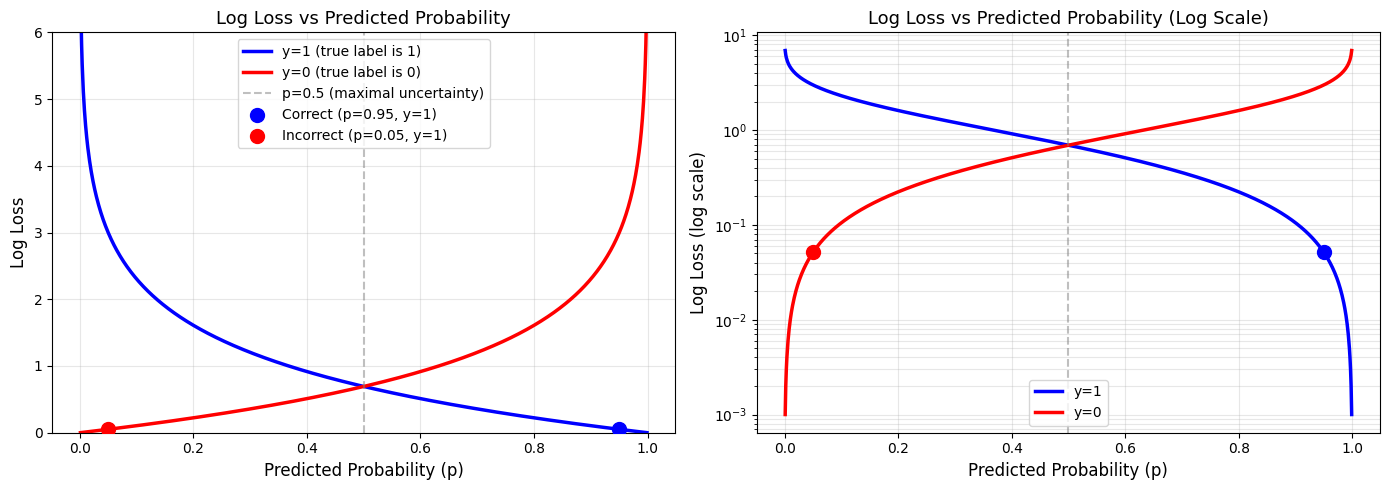


Key observations from visualization:
1. When y=1: loss decreases as p increases (we want p close to 1)
2. When y=0: loss decreases as p decreases (we want p close to 0)
3. Loss is unbounded: approaches infinity as probabilities approach 0 or 1
4. Log loss heavily penalizes confident wrong predictions
5. At p=0.95 with y=1: loss = 0.0513
6. At p=0.05 with y=1: loss = 2.9957 (much higher!)


In [11]:
# Visualize how log loss changes with predicted probability

# Create probability range
prob_range = np.linspace(0.001, 0.999, 1000)

# Calculate log loss for y=1 and y=0
log_loss_y1 = -np.log(prob_range)
log_loss_y0 = -np.log(1 - prob_range)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Log loss for both classes
ax1 = axes[0]
ax1.plot(prob_range, log_loss_y1, 'b-', linewidth=2.5, label='y=1 (true label is 1)')
ax1.plot(prob_range, log_loss_y0, 'r-', linewidth=2.5, label='y=0 (true label is 0)')
ax1.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5, label='p=0.5 (maximal uncertainty)')
ax1.scatter([0.95], [-np.log(0.95)], color='blue', s=100, zorder=5, label='Correct (p=0.95, y=1)')
ax1.scatter([0.05], [-np.log(1-0.05)], color='red', s=100, zorder=5, label='Incorrect (p=0.05, y=1)')
ax1.set_xlabel('Predicted Probability (p)', fontsize=12)
ax1.set_ylabel('Log Loss', fontsize=12)
ax1.set_title('Log Loss vs Predicted Probability', fontsize=13)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 6)

# Plot 2: Log scale to see small values
ax2 = axes[1]
ax2.semilogy(prob_range, log_loss_y1, 'b-', linewidth=2.5, label='y=1')
ax2.semilogy(prob_range, log_loss_y0, 'r-', linewidth=2.5, label='y=0')
ax2.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5)
ax2.scatter([0.95], [-np.log(0.95)], color='blue', s=100, zorder=5)
ax2.scatter([0.05], [-np.log(1-0.05)], color='red', s=100, zorder=5)
ax2.set_xlabel('Predicted Probability (p)', fontsize=12)
ax2.set_ylabel('Log Loss (log scale)', fontsize=12)
ax2.set_title('Log Loss vs Predicted Probability (Log Scale)', fontsize=13)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

print()
print("Key observations from visualization:")
print("1. When y=1: loss decreases as p increases (we want p close to 1)")
print("2. When y=0: loss decreases as p decreases (we want p close to 0)")
print("3. Loss is unbounded: approaches infinity as probabilities approach 0 or 1")
print("4. Log loss heavily penalizes confident wrong predictions")
print(f"5. At p=0.95 with y=1: loss = {-np.log(0.95):.4f}")
print(f"6. At p=0.05 with y=1: loss = {-np.log(0.05):.4f} (much higher!)")

## Example 4: Multi-class Classification

In [12]:
# Multi-class classification log loss

print()
print("="*70)
print("Example 4: Multi-class Classification Log Loss")
print("="*70)
print()

# 5 samples, 3 classes
y_true_multiclass = np.array([0, 1, 2, 0, 2])  # True class labels

# Predicted probabilities for each class
y_pred_probs_multiclass = np.array([
    [0.85, 0.10, 0.05],  # Sample 1: high prob for class 0 (correct)
    [0.10, 0.80, 0.10],  # Sample 2: high prob for class 1 (correct)
    [0.20, 0.30, 0.50],  # Sample 3: high prob for class 2 (correct)
    [0.60, 0.30, 0.10],  # Sample 4: high prob for class 0 (correct)
    [0.10, 0.10, 0.80],  # Sample 5: high prob for class 2 (correct)
])

print("True labels: ", y_true_multiclass)
print()
print("Predicted probabilities (class 0, class 1, class 2):")
for i in range(len(y_true_multiclass)):
    pred_class = np.argmax(y_pred_probs_multiclass[i])
    true_class = y_true_multiclass[i]
    correct = "✓" if pred_class == true_class else "✗"
    print(f"Sample {i+1}: {y_pred_probs_multiclass[i]} [True={true_class}, Pred={pred_class}] {correct}")

print()

# Calculate multi-class log loss
individual_multiclass_losses = []
for i in range(len(y_true_multiclass)):
    true_class = y_true_multiclass[i]
    pred_prob = y_pred_probs_multiclass[i, true_class]
    sample_loss = -np.log(pred_prob)
    individual_multiclass_losses.append(sample_loss)
    print(f"Sample {i+1}: -log(p_true_class) = -log({pred_prob:.3f}) = {sample_loss:.6f}")

manual_multiclass_loss = multiclass_log_loss(y_true_multiclass, y_pred_probs_multiclass)
print()
print(f"Manual calculation (mean): {manual_multiclass_loss:.6f}")
print(f"Multi-class Log Loss:      {manual_multiclass_loss:.6f}")


Example 4: Multi-class Classification Log Loss

True labels:  [0 1 2 0 2]

Predicted probabilities (class 0, class 1, class 2):
Sample 1: [0.85 0.1  0.05] [True=0, Pred=0] ✓
Sample 2: [0.1 0.8 0.1] [True=1, Pred=1] ✓
Sample 3: [0.2 0.3 0.5] [True=2, Pred=2] ✓
Sample 4: [0.6 0.3 0.1] [True=0, Pred=0] ✓
Sample 5: [0.1 0.1 0.8] [True=2, Pred=2] ✓

Sample 1: -log(p_true_class) = -log(0.850) = 0.162519
Sample 2: -log(p_true_class) = -log(0.800) = 0.223144
Sample 3: -log(p_true_class) = -log(0.500) = 0.693147
Sample 4: -log(p_true_class) = -log(0.600) = 0.510826
Sample 5: -log(p_true_class) = -log(0.800) = 0.223144

Manual calculation (mean): 0.362556
Multi-class Log Loss:      0.362556


## Example 5: Comparing Different Prediction Scenarios

In [13]:
# Compare how log loss behaves for different prediction scenarios

print()
print("="*70)
print("Example 5: Comparing Prediction Scenarios")
print("="*70)
print()

# Dataset: predict if an email is spam (1) or not (0)
y_true = np.array([1, 1, 0, 0, 1, 0, 1, 0])

# Different models' predictions
model1_probs = np.array([0.9, 0.85, 0.1, 0.15, 0.88, 0.12, 0.92, 0.08])  # Good model
model2_probs = np.array([0.6, 0.55, 0.4, 0.45, 0.58, 0.42, 0.62, 0.38])  # Okay model
model3_probs = np.array([0.1, 0.2, 0.85, 0.9, 0.15, 0.95, 0.05, 0.92])   # Bad model (opposite)

# Calculate log loss for each model
loss1 = mean_binary_log_loss(y_true, model1_probs)
loss2 = mean_binary_log_loss(y_true, model2_probs)
loss3 = mean_binary_log_loss(y_true, model3_probs)

print(f"Dataset:      {y_true}")
print()
print("Model 1 (Good): ", model1_probs)
print(f"  Log Loss: {loss1:.6f}")
print()
print("Model 2 (Okay): ", model2_probs)
print(f"  Log Loss: {loss2:.6f}")
print()
print("Model 3 (Bad):  ", model3_probs)
print(f"  Log Loss: {loss3:.6f}")
print()
print("Ranking (lower is better):")
scores = [(1, loss1), (2, loss2), (3, loss3)]
scores.sort(key=lambda x: x[1])
for rank, (model, loss) in enumerate(scores, 1):
    print(f"  {rank}. Model {model}: {loss:.6f}")
print()
print(f"Ratio of bad to good model: {loss3/loss1:.1f}x")
print(f"This shows how severely log loss penalizes confident wrong predictions!")


Example 5: Comparing Prediction Scenarios

Dataset:      [1 1 0 0 1 0 1 0]

Model 1 (Good):  [0.9  0.85 0.1  0.15 0.88 0.12 0.92 0.08]
  Log Loss: 0.119774

Model 2 (Okay):  [0.6  0.55 0.4  0.45 0.58 0.42 0.62 0.38]
  Log Loss: 0.532856

Model 3 (Bad):   [0.1  0.2  0.85 0.9  0.15 0.95 0.05 0.92]
  Log Loss: 2.315755

Ranking (lower is better):
  1. Model 1: 0.119774
  2. Model 2: 0.532856
  3. Model 3: 2.315755

Ratio of bad to good model: 19.3x
This shows how severely log loss penalizes confident wrong predictions!


## When to Use Log Loss

**Log Loss** is the ideal choice for classification tasks where you need probability estimates and want to penalize confident misclassifications heavily. Here's when to use it:

### ✓ Use Log Loss When:

1. **Binary Classification**
   - Predicting one of two classes (spam/not spam, positive/negative, default/no default)
   - Standard loss function for logistic regression
   - Default for most binary classification models

2. **Multi-class Classification**
   - Predicting one of K classes (image classification, text categorization)
   - FormName: Cross-Entropy Loss for categorical problems
   - Used with softmax activation in neural networks

3. **Probability Outputs Required**
   - You need calibrated probability estimates, not just class predictions
   - Decision thresholds can be adjusted based on probability outputs
   - Confidence in predictions matters for downstream decisions

4. **Imbalanced Datasets**
   - Log loss is sensitive to individual errors, especially confident wrong predictions
   - Better for imbalanced datasets compared to accuracy-based metrics
   - Can be combined with class weights for severely imbalanced data

5. **Neural Networks**
   - Standard loss for classification neural networks
   - Differentiable and works well with gradient descent
   - Compatible with softmax (multi-class) and sigmoid (binary) outputs

6. **Kaggle and Competition Datasets**
   - Often the evaluation metric for classification competitions
   - Benchmark loss function for comparing models

### ✗ Don't Use Log Loss When:

1. **Regression Problems**
   - Use MSE, MAE, or RMSE for predicting continuous values
   - Log loss requires discrete class labels

2. **Ranking Problems**
   - Use ranking losses (e.g., pairwise losses)
   - Log loss doesn't capture ranking relationships

3. **Only Class Labels Matter (Not Probabilities)**
   - If only binary correctness matters (not confidence)
   - Use 0-1 loss or accuracy metric
   - Better to use accuracy if training/deployment budget is very limited

4. **Extreme Imbalance with Rare Classes**
   - May need focal loss or weighted variants
   - Standard log loss can be dominated by majority class

5. **Bounded Loss Needed**
   - Log loss is unbounded (approaches infinity for very wrong predictions)
   - If you need bounded loss (e.g., 0 to 1), use squared loss instead

### Comparison with Other Loss Functions:

| Loss Function | Use Case | Bounded | Penalizes Confidence |
|---|---|---|---|
| **Log Loss** | Classification with probability outputs | No | Yes (high penalty) |
| **Squared Loss** | Regression or regression-like classification | Yes (0-1) | Yes (moderate) |
| **Hinge Loss** | SVM-style margin-based classification | Yes | No |
| **0-1 Loss** | Pure accuracy-based classification | Yes | No |
| **Focal Loss** | Highly imbalanced classification | No | Yes (adjustable) |